# ResNet-50 + Wavelet Features (Hybrid) — Breast Cancer Classification
Based on: Mohanty & Das (2025), *ResNet-50 backbone + wavelet features for complementary information*.

Pipeline structure mirrors the EfficientNetB3 baseline notebook: frozen ImageNet backbone → pooled deep features,
fused with handcrafted wavelet features → dense classifier head. Same callbacks, same metrics (F1/Precision/Recall),
same evaluation + classification report + confusion matrix flow.

In [1]:
# ==========================================================
# INSTALL WAVELET LIBRARY (only needed once per environment)
# ==========================================================
# !pip install PyWavelets

print("start")

import os

Imbalanced_dataset = r"D:\Thesis_folder\Supervised_Imbalanced"

print("Imbalanced dataset ready")


start
Imbalanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence, to_categorical
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Supervised_Imbalanced"

IMAGE_SIZE = (288, 288)          # native ResNet-50 input size
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 150

WAVELET_NAME = "db1"             # Daubechies-1 (Haar), matches common breast-cancer wavelet studies
WAVELET_LEVEL = 2                # decomposition depth -> richer complementary features

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [5]:
# ==========================================================
# WAVELET FEATURE EXTRACTION
# ==========================================================
# For each image we take a 2D Discrete Wavelet Transform (DWT) of the grayscale
# version, then summarise every sub-band (approximation + horizontal/vertical/
# diagonal detail) with mean, std and energy. This gives a compact, complementary
# texture descriptor that is concatenated with the ResNet-50 deep features,
# following the "ResNet-50 backbone + wavelet features for complementary
# information" design in Mohanty & Das (2025).

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    """
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector
    """
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)

    features = []
    for idx, c in enumerate(coeffs):
        if idx == 0:
            # approximation coefficients (single array)
            sub_bands = [c]
        else:
            # detail coefficients: tuple of (cH, cV, cD)
            sub_bands = list(c)

        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)  # normalised energy

    return np.array(features, dtype=np.float32)


def get_wavelet_feature_dim():
    """Run once on a dummy image to determine the wavelet feature vector length."""
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Wavelet feature vector length: {WAVELET_FEATURE_DIM}")


Wavelet feature vector length: 21


In [6]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet branch)
# ==========================================================
# ImageDataGenerator.flow_from_directory only yields (image, label) pairs, so a
# custom Sequence is used here to additionally compute the wavelet feature
# vector for every image in the batch. Directory layout is identical to the
# EfficientNetB3 notebook: DATASET_PATH/{train,val,test}/<class_name>/*.jpg

class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = {name: i for i, name in enumerate(self.class_names)}

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_indices[cls])

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            # Wavelet branch computed on the raw (0-255) resized image
            batch_wavelets[i] = extract_wavelet_features(img_rgb)

            # ResNet-50 branch uses its own preprocessing (caffe-style mean subtraction)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32).copy())

            batch_labels[i] = to_categorical(self.labels[fi], num_classes=self.num_classes)

        return (batch_images, batch_wavelets), batch_labels

    # Convenience properties to mirror ImageDataGenerator API used later in the notebook
    @property
    def classes(self):
        return self.labels

    @property
    def class_indices_(self):
        return self.class_indices


train_generator = ResNetWaveletGenerator(train_dir, shuffle=True)
val_generator = ResNetWaveletGenerator(val_dir, shuffle=False)
test_generator = ResNetWaveletGenerator(test_dir, shuffle=False)

print("Classes found:", train_generator.class_names)
print("Train / Val / Test sizes:",
      len(train_generator.filepaths), len(val_generator.filepaths), len(test_generator.filepaths))


Classes found: ['Benign', 'Malignant', 'Normal']
Train / Val / Test sizes: 13811 2960 2960


In [7]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet MLP (feature branch)
# ==========================================================
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = tf.keras.metrics.Precision(name='precision')
recall_metric = tf.keras.metrics.Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid():
    # ---- Image branch: ResNet-50 (frozen, ImageNet weights) ----
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(0.3)(x_img)

    # ---- Wavelet branch: small MLP over handcrafted features ----
    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu')(x_wav)
    x_wav = Dropout(0.3)(x_wav)

    # ---- Fusion + classifier head ----
    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu')(fused)
    fused = Dropout(0.3)(fused)
    output = Dense(NUM_CLASSES, activation='softmax')(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model

model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [8]:
# ==========================================================
# CALLBACKS (Monitor set to 'val_f1_score')
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=16,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=5e-8,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "ResNet50_Wavelet_Hybrid_Imbalanced_model.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("done")


start
done


In [9]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [10]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
print("done")


start
Epoch 1/150
432/432 [==============================] - ETA: 0s - loss: 0.9263 - accuracy: 0.5596 - f1_score: 0.5497 - precision: 0.6135 - recall: 0.4428
Epoch 1: val_f1_score improved from -inf to 0.65390, saving model to ResNet50_Wavelet_Hybrid_Imbalanced_model.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
432/432 [==============================] - 258s 590ms/step - loss: 0.9263 - accuracy: 0.5596 - f1_score: 0.5497 - precision: 0.6135 - recall: 0.4428 - val_loss: 0.7507 - val_accuracy: 0.6510 - val_f1_score: 0.6539 - val_precision: 0.7370 - val_recall: 0.5169 - lr: 1.0000e-04
Epoch 2/150
432/432 [==============================] - ETA: 0s - loss: 0.7776 - accuracy: 0.6316 - f1_score: 0.6234 - precision: 0.6965 - recall: 0.5346
Epoch 2: val_f1_score improved from 0.65390 to 0.65990, saving model to ResNet50_Wavelet_Hybrid_Imbalanced_model.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
432/432 [==============================] - 199s 461ms/step - loss: 0.7776 - accuracy: 0.6

In [11]:
# 1. Rebuild the model architecture blueprint first
model = get_ResNet50_Wavelet_Hybrid()

# 2. Load the weights directly into the blueprint
model.load_weights("ResNet50_Wavelet_Hybrid_Imbalanced_model.h5")

print("Model weights loaded successfully!")


Model weights loaded successfully!


start


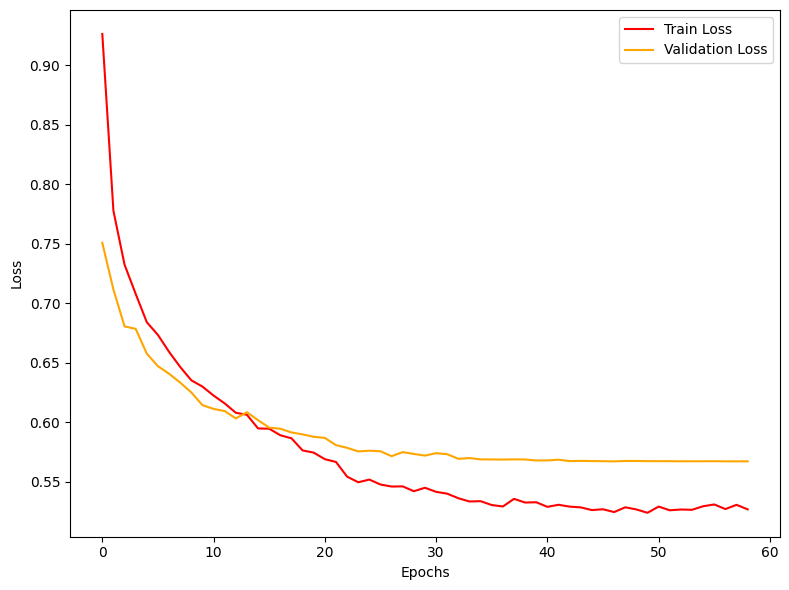

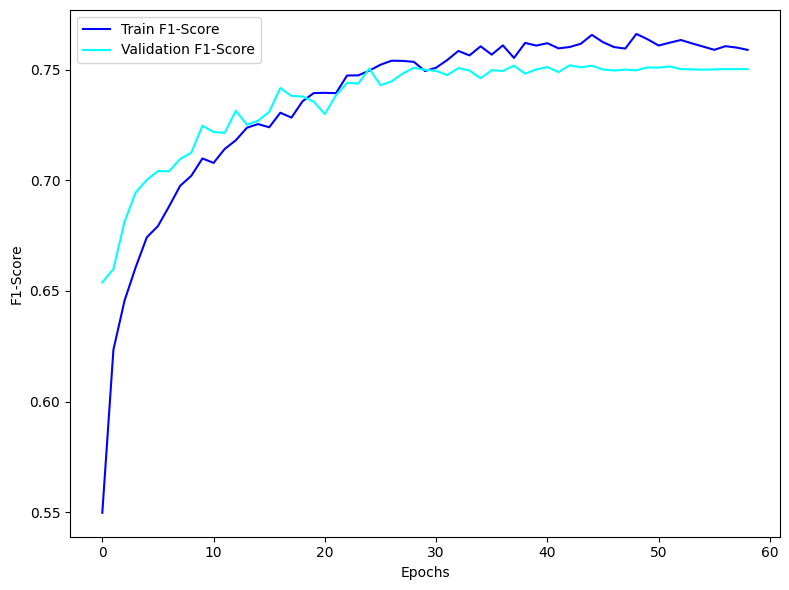

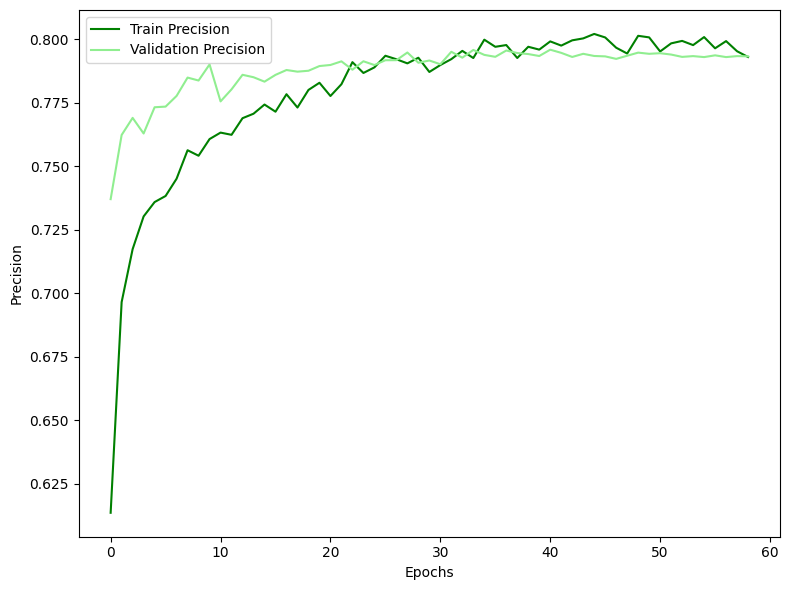

done1


In [12]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# ==========================================================
print("start")

# 1. Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_Loss_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 2. F1 Score Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['f1_score'], label='Train F1-Score', color='blue')
plt.plot(history.history['val_f1_score'], label='Validation F1-Score', color='cyan')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_F1_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 3. Precision Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['precision'], label='Train Precision', color='green')
plt.plot(history.history['val_precision'], label='Validation Precision', color='lightgreen')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_Precision_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


In [13]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

# Order: [loss, accuracy, f1_score, precision, recall]
train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

print("\n" + "="*40)
print("TRAINING METRICS")
print("="*40)
print(f"Training Loss      : {train_loss:.4f}")
print(f"Training Accuracy  : {train_acc*100:.2f}%")
print(f"Training F1-Score  : {train_f1*100:.2f}%")
print(f"Training Precision : {train_precision*100:.2f}%")
print(f"Training Recall    : {train_recall*100:.2f}%")

print("\n" + "="*40)
print("VALIDATION METRICS")
print("="*40)
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_acc*100:.2f}%")
print(f"Validation F1-Score  : {val_f1*100:.2f}%")
print(f"Validation Precision : {val_precision*100:.2f}%")
print(f"Validation Recall    : {val_recall*100:.2f}%")

print("\n" + "="*40)
print("TESTING METRICS (UNSEEN DATA)")
print("="*40)
print(f"Testing Loss      : {test_loss:.4f}")
print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print(f"Testing F1-Score  : {test_f1*100:.2f}%")
print(f"Testing Precision : {test_precision*100:.2f}%")
print(f"Testing Recall    : {test_recall*100:.2f}%")


Evaluating on Training Set...
432/432 [==============================] - 166s 382ms/step - loss: 0.4701 - accuracy: 0.8021 - f1_score: 0.7940 - precision: 0.8315 - recall: 0.7372

Evaluating on Validation Set...
93/93 [==============================] - 34s 366ms/step - loss: 0.5673 - accuracy: 0.7520 - f1_score: 0.7520 - precision: 0.7930 - recall: 0.6936

Evaluating on Testing Set (Truly Unseen)...
93/93 [==============================] - 44s 471ms/step - loss: 0.5594 - accuracy: 0.7480 - f1_score: 0.7466 - precision: 0.7881 - recall: 0.6885

TRAINING METRICS
Training Loss      : 0.4701
Training Accuracy  : 80.21%
Training F1-Score  : 79.40%
Training Precision : 83.15%
Training Recall    : 73.72%

VALIDATION METRICS
Validation Loss      : 0.5673
Validation Accuracy  : 75.20%
Validation F1-Score  : 75.20%
Validation Precision : 79.30%
Validation Recall    : 69.36%

TESTING METRICS (UNSEEN DATA)
Testing Loss      : 0.5594
Testing Accuracy  : 74.80%
Testing F1-Score  : 74.66%
Testing Pre

In [14]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = test_generator.class_names

print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")



Calculating Precision, Recall, F1-score on Test Set...
93/93 [==============================] - 33s 352ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.67      0.58      0.62       911
   Malignant       0.74      0.79      0.77      1263
      Normal       0.83      0.88      0.85       786

    accuracy                           0.75      2960
   macro avg       0.75      0.75      0.75      2960
weighted avg       0.74      0.75      0.74      2960

done1


Generating Confusion Matrix...


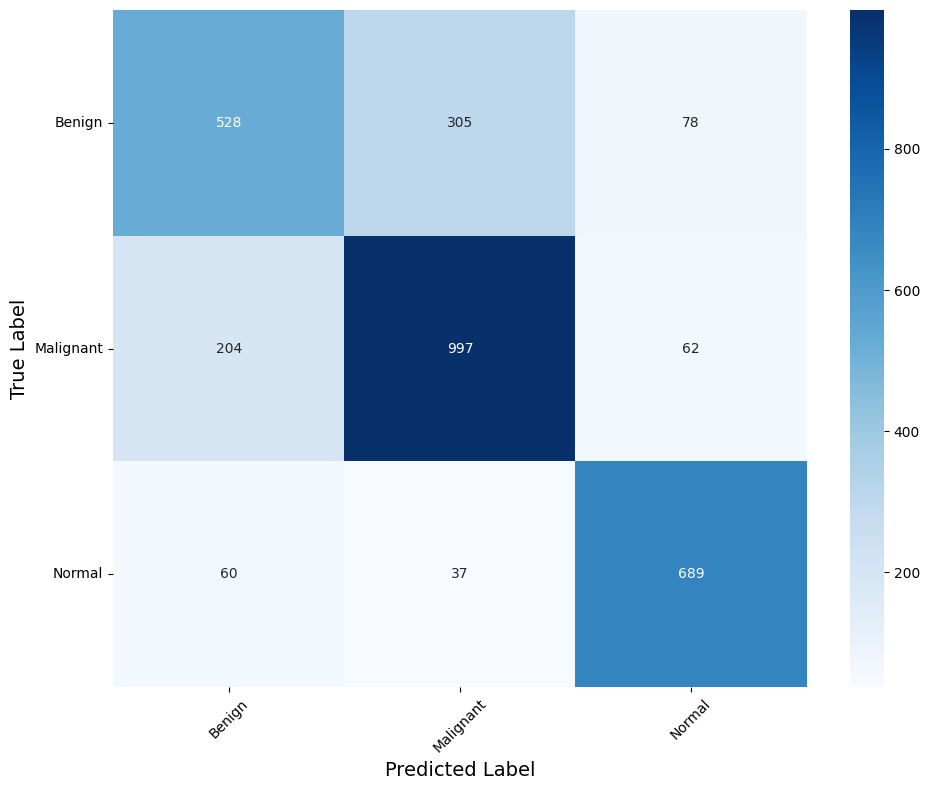

done1


In [15]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")
